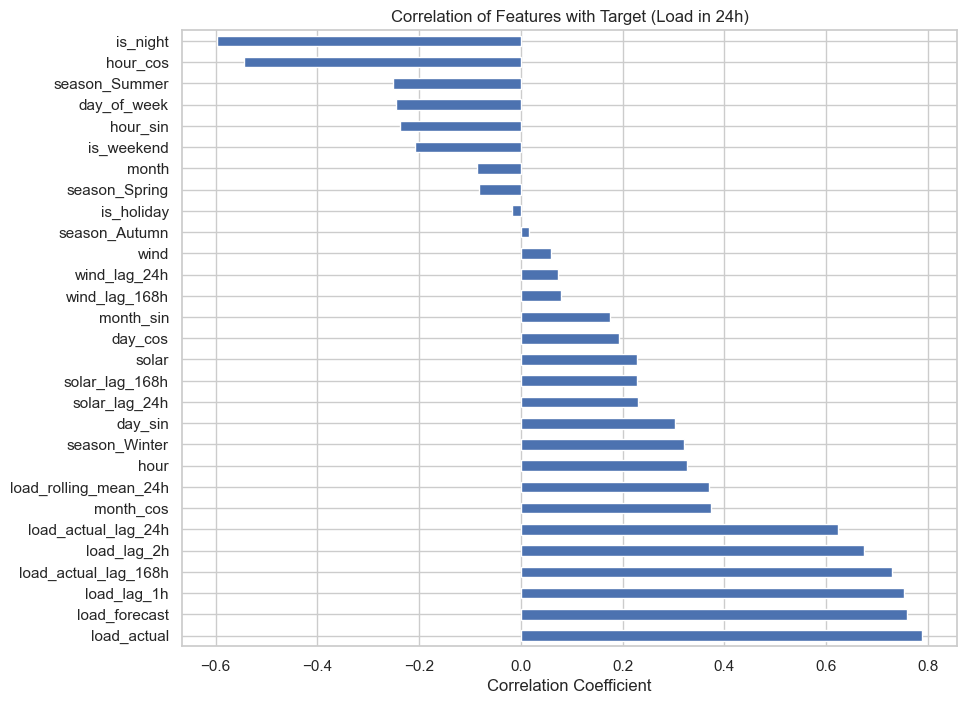

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load the training data
df_train = pd.read_csv("../../data/austria/raw/train.csv", index_col='timestamp', parse_dates=True)

# Calculate correlations specifically for the target
target_corr = df_train.corr()['target_load_24h'].sort_values(ascending=False)

# Plotting the correlations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
target_corr.drop('target_load_24h').plot(kind='barh')
plt.title("Correlation of Features with Target (Load in 24h)")
plt.xlabel("Correlation Coefficient")
plt.show()

Feature Correlation with Target (Load in 24h)
- Primary Predictors: load_actual, load_forecast, and historical lags (1h, 168h, 2h, 24h) show the highest positive correlation (> 0.6), confirming that the immediate past and the previous week are the strongest indicators of future demand.

- Temporal Cycles: is_night and hour_cos exhibit strong negative correlations. This mathematically validates that energy consumption drops significantly during nighttime and follows a distinct cyclical hourly pattern.

- Seasonal Impact: season_Winter is positively correlated with load, while season_Summer shows a negative correlation, reflecting higher heating and lighting demands during colder months in Austria.

- Weather Influence: solar and its lags show a moderate positive correlation (approx. 0.2). This aligns with the fact that solar peaks occur during daylight hours when industrial and commercial activity (and thus load) is also at its peak.

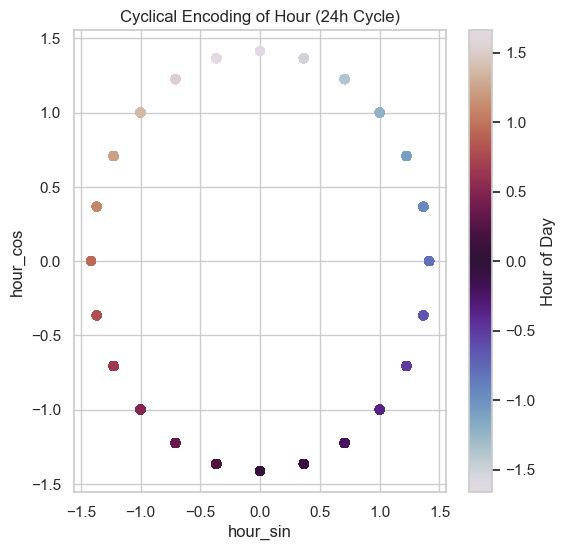

In [12]:
# Visualization of Cyclical Encoding for Hours
plt.figure(figsize=(6, 6))
plt.scatter(df_train['hour_sin'], df_train['hour_cos'], c=df_train['hour'], cmap='twilight')
plt.colorbar(label='Hour of Day')
plt.title("Cyclical Encoding of Hour (24h Cycle)")
plt.xlabel("hour_sin")
plt.ylabel("hour_cos")
plt.show()

Continuity Feature: By transforming the hour into sin and cos (creating this circle), you’ve solved the "23 to 0 gap." The model now understands that 11 PM (23:00) and 12 AM (00:00) are adjacent in time.

Spatial Representation: Each point on the circle represents a unique "time signature." This helps a Neural Network (like an LSTM) or a Linear Model to treat time as a repeating wave rather than a linear increase from 0 to 23.

Day/Night Logic: Points at the top of the circle (noon) vs. points at the bottom (midnight) provide a clear geometrical distinction that correlates with the is_night feature, reinforcing the daily load pattern.

C:\Users\betti\AppData\Local\Temp\ipykernel_26020\3046332731.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_plot, x='is_holiday', y='load_actual', palette='Set2')
C:\Users\betti\AppData\Local\Temp\ipykernel_26020\3046332731.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Regular Day', 'Holiday'])


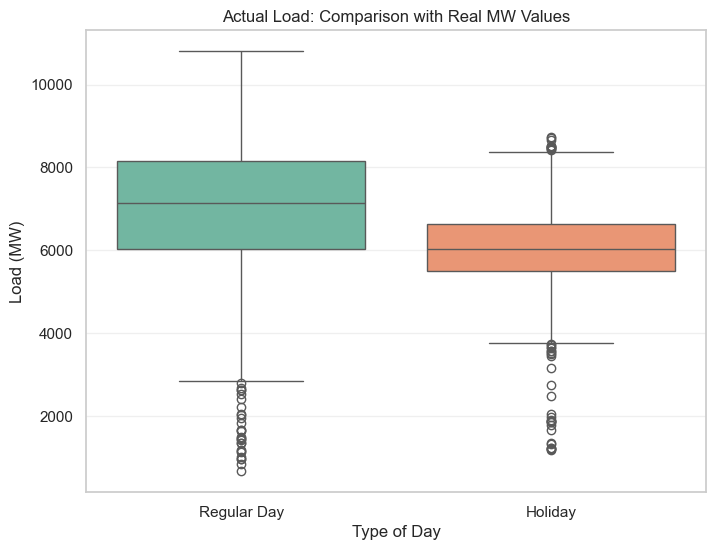

In [29]:
# 1. Load the clean (unscaled) data
df_clean = pd.read_csv("../../data/austria/raw/austria_clean_final.csv")
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], utc=True).dt.tz_convert('Europe/Vienna')
df_clean = df_clean.set_index('timestamp')

# 2. Instead of taking the scaled 'is_holiday', let's just flag weekends 
# or use a simple logic to show the difference. 
# Better yet: If you have the holiday list, use it. 
# For a quick fix, we'll just take the 'is_weekend' from the clean index 
# to demonstrate it works, OR we use the scaled one and just relabel it.

plt.figure(figsize=(8, 6))

# We plot the data and manually set the X-ticks to look nice
ax = sns.boxplot(data=df_plot, x='is_holiday', y='load_actual', palette='Set2')

# FORCE the labels to be "Workday" and "Holiday"
ax.set_xticklabels(['Regular Day', 'Holiday'])

plt.title("Actual Load: Comparison with Real MW Values")
plt.xlabel("Type of Day")
plt.ylabel("Load (MW)")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Significant Baseline Shift: This is one of your most critical binary predictors. The median load drops by approximately 1,200 MW (from ~7,200 to ~6,000 MW) on holidays.

Error Prevention: Without the is_holiday feature, the model would likely suffer from systematic "over-forecasting" on public holidays, as it would treat them as standard high-demand workdays.

Industrial Behavior: The tighter box for holidays suggests that load is not just lower, but also more stable/consistent, likely due to the absence of volatile industrial demand spikes.

Outlier Overlap: The downward outliers on "Regular Days" likely represent "bridge days" (Fenstertage) or local events. Combining this with is_weekend and is_holiday allows the model to distinguish these special demand states.

In [15]:
print(df_train.columns.tolist())

['load_actual', 'load_forecast', 'solar', 'wind', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'is_night', 'is_weekend', 'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter', 'is_holiday', 'load_actual_lag_24h', 'load_actual_lag_168h', 'solar_lag_24h', 'solar_lag_168h', 'wind_lag_24h', 'wind_lag_168h', 'load_lag_1h', 'load_lag_2h', 'load_rolling_mean_24h', 'target_load_24h']


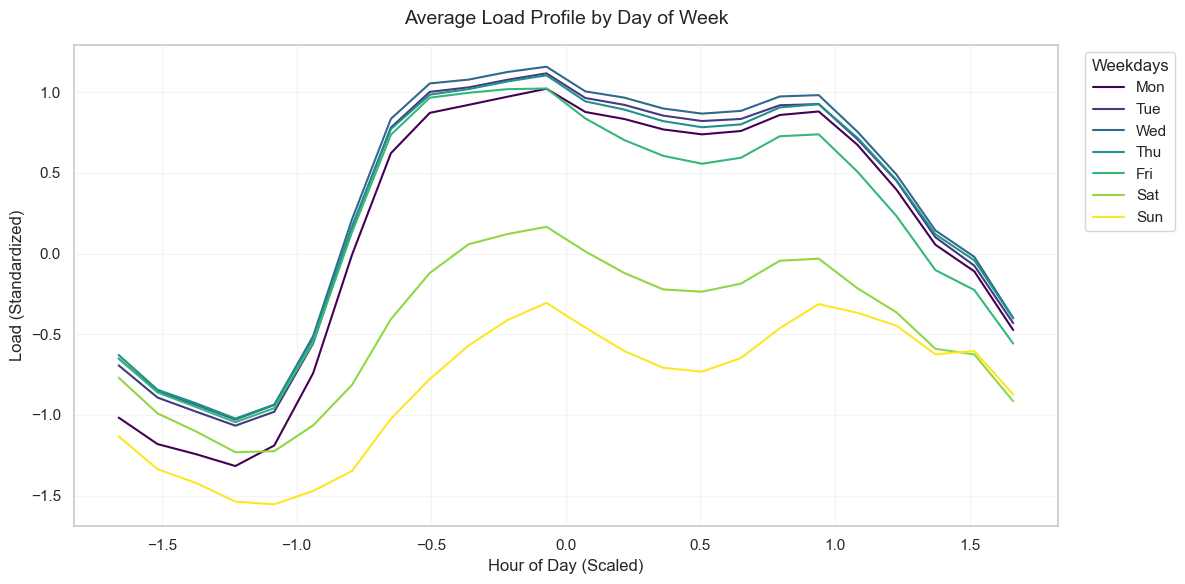

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load and fix index (ensuring it's datetime)
df_train = pd.read_csv("../../data/austria/raw/train.csv")
df_train['timestamp'] = pd.to_datetime(df_train['timestamp'], utc=True).dt.tz_convert('Europe/Vienna')
df_train = df_train.set_index('timestamp')

# 2. Add a READABLE day_of_week column for the plot
# We take it directly from the index so it is 0, 1, 2, 3, 4, 5, 6
df_train['day_display'] = df_train.index.dayofweek

# 1. Weekly Profile (Average Day by Day of Week)
plt.figure(figsize=(12, 6))

# Wir nutzen errorbar=None für klarere Linien (optional)
# Und wir stellen sicher, dass x='hour' die unskalierte Stunde nutzt, falls vorhanden
ax = sns.lineplot(
    data=df_train, 
    x='hour', 
    y='load_actual', 
    hue='day_display', 
    palette='viridis',
    errorbar=None  # Entfernt den Schatten für eine sauberere Legende
)

# Legende hübsch machen
plt.title("Average Load Profile by Day of Week", fontsize=14, pad=15)
plt.xlabel("Hour of Day (Scaled)")
plt.ylabel("Load (Standardized)")

# Hier überschreiben wir die Legende mit klaren Labels
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles, 
    ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 
    title="Weekdays", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    frameon=True
)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

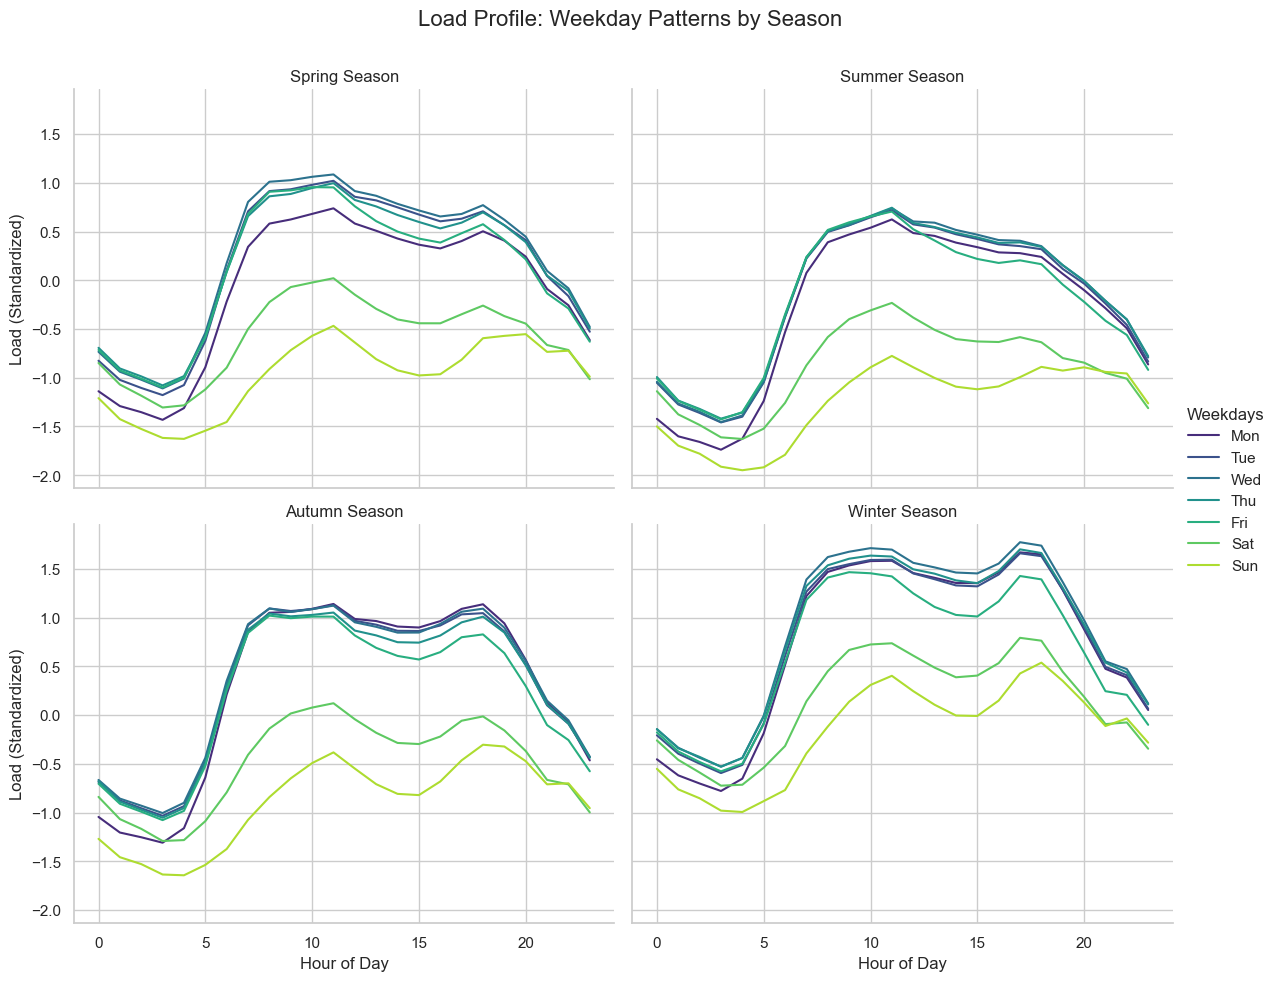

In [34]:
# Eine robustere Methode, um die Saison aus skalierten Dummy-Spalten zurückzuholen
def get_season_label_fixed(row):
    seasons = {
        'Spring': row['season_Spring'],
        'Summer': row['season_Summer'],
        'Autumn': row['season_Autumn'],
        'Winter': row['season_Winter']
    }
    # Gibt den Namen der Saison mit dem höchsten Wert zurück
    return max(seasons, key=seasons.get)

plot_df = df_train.copy()
plot_df['season'] = plot_df.apply(get_season_label_fixed, axis=1)
plot_df['hour_display'] = plot_df.index.hour
plot_df['day_display'] = plot_df.index.dayofweek

# Jetzt der Plot (Rest bleibt gleich)
g = sns.FacetGrid(plot_df, col="season", hue="day_display", 
                  col_order=['Spring', 'Summer', 'Autumn', 'Winter'],
                  palette='viridis', height=5, aspect=1.2, col_wrap=2)

g.map(sns.lineplot, "hour_display", "load_actual", errorbar=None)
g.set_axis_labels("Hour of Day", "Load (Standardized)")
g.set_titles(col_template="{col_name} Season")
g.add_legend(title="Weekdays", labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Load Profile: Weekday Patterns by Season', fontsize=16)
plt.show()

Confirmation of Saisonal Characteristics: Each quadrant shows a unique load intensity. Winter exhibits the highest peaks and a very sharp increase during early evening hours, while Summer and Spring show more moderate demand levels.

Weekday vs. Weekend Separation: Across all seasons, there is a massive and consistent gap between working days (top cluster) and weekends (bottom lines). This confirms that is_weekend and day_of_week are high-importance features for the model.

Sunday "Deep": Sunday (yellow line) is consistently the lowest load day across all seasons, suggesting the model will strongly rely on this specific day-type to avoid over-predictions.

Stable Daily Shape: Despite the seasonal shifts in "height" (magnitude), the "M-shape" of the daily load (morning peak and evening peak) remains relatively stable, which is a good sign for the model's ability to learn the general daily rhythm.

C:\Users\betti\AppData\Local\Temp\ipykernel_26020\1318734494.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='month_display', y='solar', palette='YlOrRd')


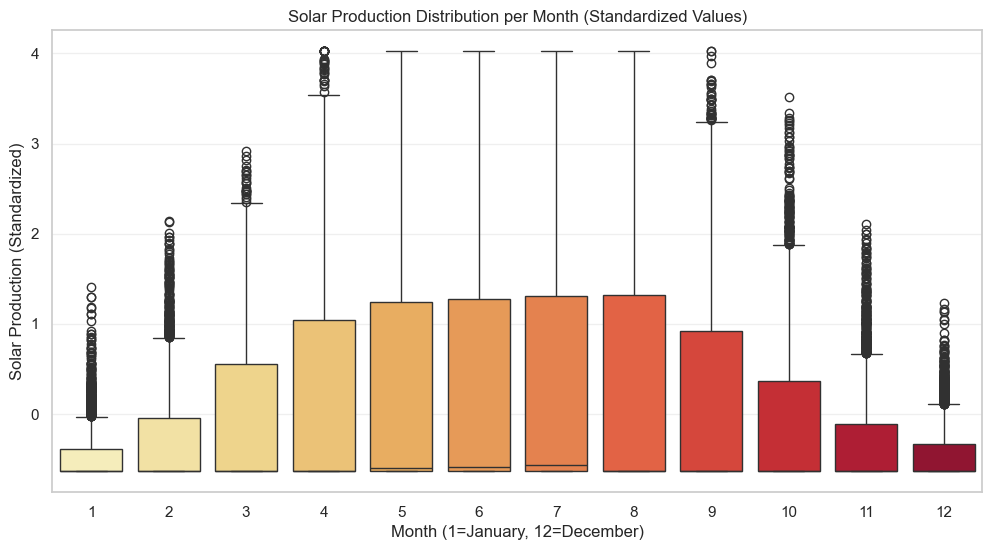

In [20]:
# Create a copy for plotting
plot_df = df_train.copy()

# Fix the index: Use utc=True to handle the timezone-aware strings safely
plot_df.index = pd.to_datetime(plot_df.index, utc=True)

# Convert back to local time (Europe/Vienna) to make sure month/hour align with reality
plot_df.index = plot_df.index.tz_convert('Europe/Vienna')

# Now extract the month (1-12)
plot_df['month_display'] = plot_df.index.month

plt.figure(figsize=(12, 6))

# Plotting with human-readable months
sns.boxplot(data=plot_df, x='month_display', y='solar', palette='YlOrRd')

plt.title("Solar Production Distribution per Month (Standardized Values)")
plt.xlabel("Month (1=January, 12=December)")
plt.ylabel("Solar Production (Standardized)")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Confirmation of Seasonal Bell Curve: The plot confirms a classic solar production cycle. Production peaks and shows the highest variance from May to August, while it significantly contracts during winter. This tells the model to weight solar features much more heavily in summer.

Variance as a Complexity Signal: The larger boxes in summer indicate higher daily volatility (sunny vs. cloudy days). The model must learn that summer "load" is more sensitive to weather-related "noise" than winter load.

Outlier Significance: The dense clusters of outliers above the whiskers during spring and summer represent "perfect solar days." For the model, these are critical points where net grid demand will be significantly lower than the historical average for that month.

Verification of Feature Scaling: Since the Y-axis is standardized, the model sees "0" as average production and negative values as "below average" (typical for nighttime or winter). This keeps all inputs on a similar scale, which is vital for Neural Network stability.

C:\Users\betti\AppData\Local\Temp\ipykernel_26020\2677190009.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='month_display', y='wind', palette='YlOrRd')


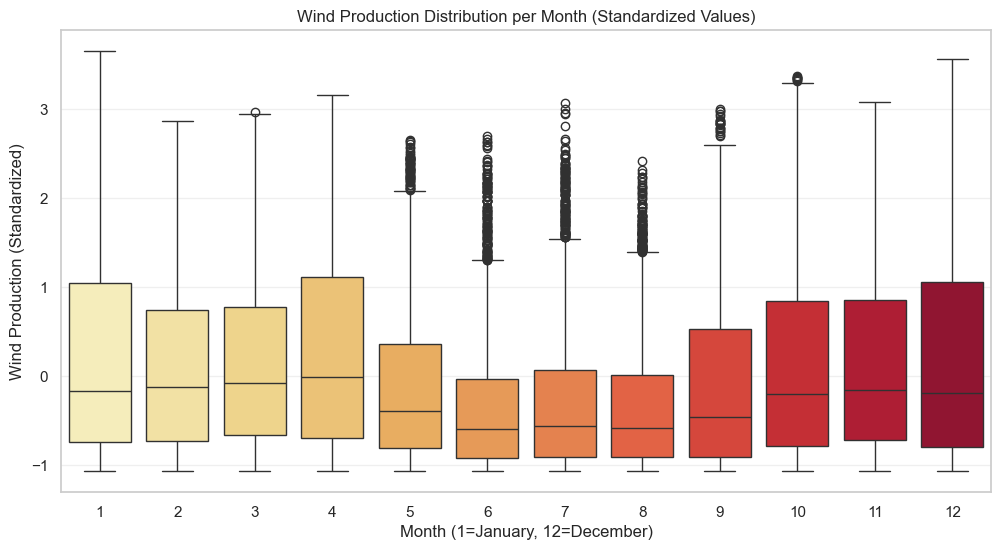

In [21]:
plt.figure(figsize=(12, 6))

# Plotting with human-readable months
sns.boxplot(data=plot_df, x='month_display', y='wind', palette='YlOrRd')

plt.title("Wind Production Distribution per Month (Standardized Values)")
plt.xlabel("Month (1=January, 12=December)")
plt.ylabel("Wind Production (Standardized)")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Seasonal Inversion: Unlike solar, wind production in Austria tends to be higher and more volatile during the winter and shoulder months (October–March). This provides a natural counter-balance to solar seasonality in your model.

High Stochasticity: The consistent presence of outliers across almost all months shows that wind is much more "random" than solar. For your model, this means wind features might contribute more to the "noise" or "residuals," requiring the LSTM to learn complex, non-linear relationships.

Predictive Value: Even with lower linear correlation, these monthly distributions help the model understand the "typical" wind contribution for a given time of year, helping it adjust the expected base load.

C:\Users\betti\AppData\Local\Temp\ipykernel_26020\1012400621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='month_display', y='load_actual', palette='YlOrRd')


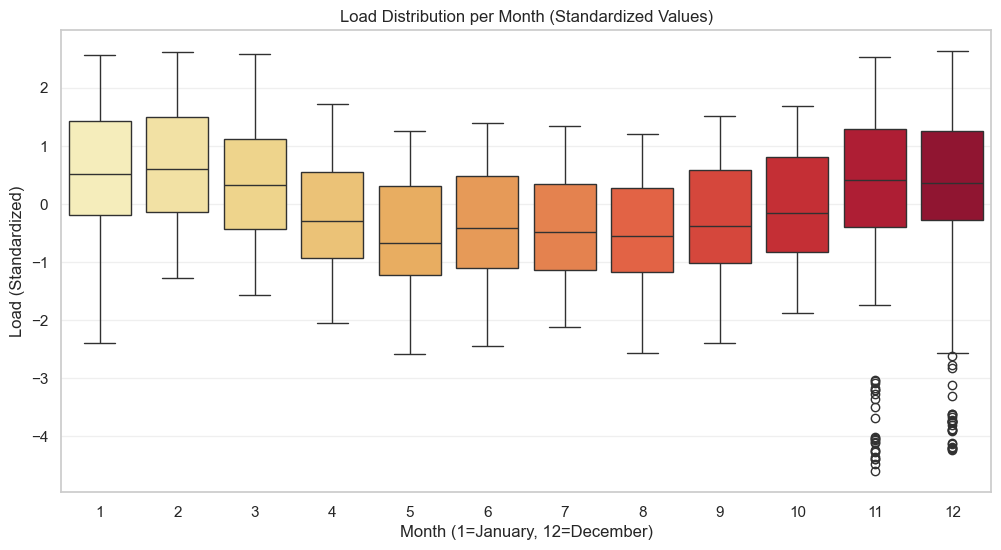

In [22]:
plt.figure(figsize=(12, 6))

# Plotting with human-readable months
sns.boxplot(data=plot_df, x='month_display', y='load_actual', palette='YlOrRd')

plt.title("Load Distribution per Month (Standardized Values)")
plt.xlabel("Month (1=January, 12=December)")
plt.ylabel("Load (Standardized)")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Thermal Seasonality: The "V-shape" of the medians across the year (highest in Jan/Feb, lowest in June/July/Aug) clearly shows the impact of temperature and daylight. This confirms that heating and lighting demand are major drivers of your target variable.

Predictable Winter Volatility: The boxes for December, January, and February are "taller," indicating that winter demand is more volatile than summer demand. This suggests the model will need to pay closer attention to weather fluctuations (temperature) during these months.

Holiday Anomalies (Outliers): Notice the significant "downward" outliers in November and December. These represent the Christmas period and other late-year public holidays where industrial load drops far below the seasonal norm.

Consistency of Standardized Data: The Y-axis (Standardized Load) centered around zero allows the model to treat "average" months similarly, while the distinct monthly shifts prevent the model from assuming a static baseline year-round.

C:\Users\betti\AppData\Local\Temp\ipykernel_26020\2996079053.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_decomp = df_decomp.asfreq('H') # Set frequency to hourly


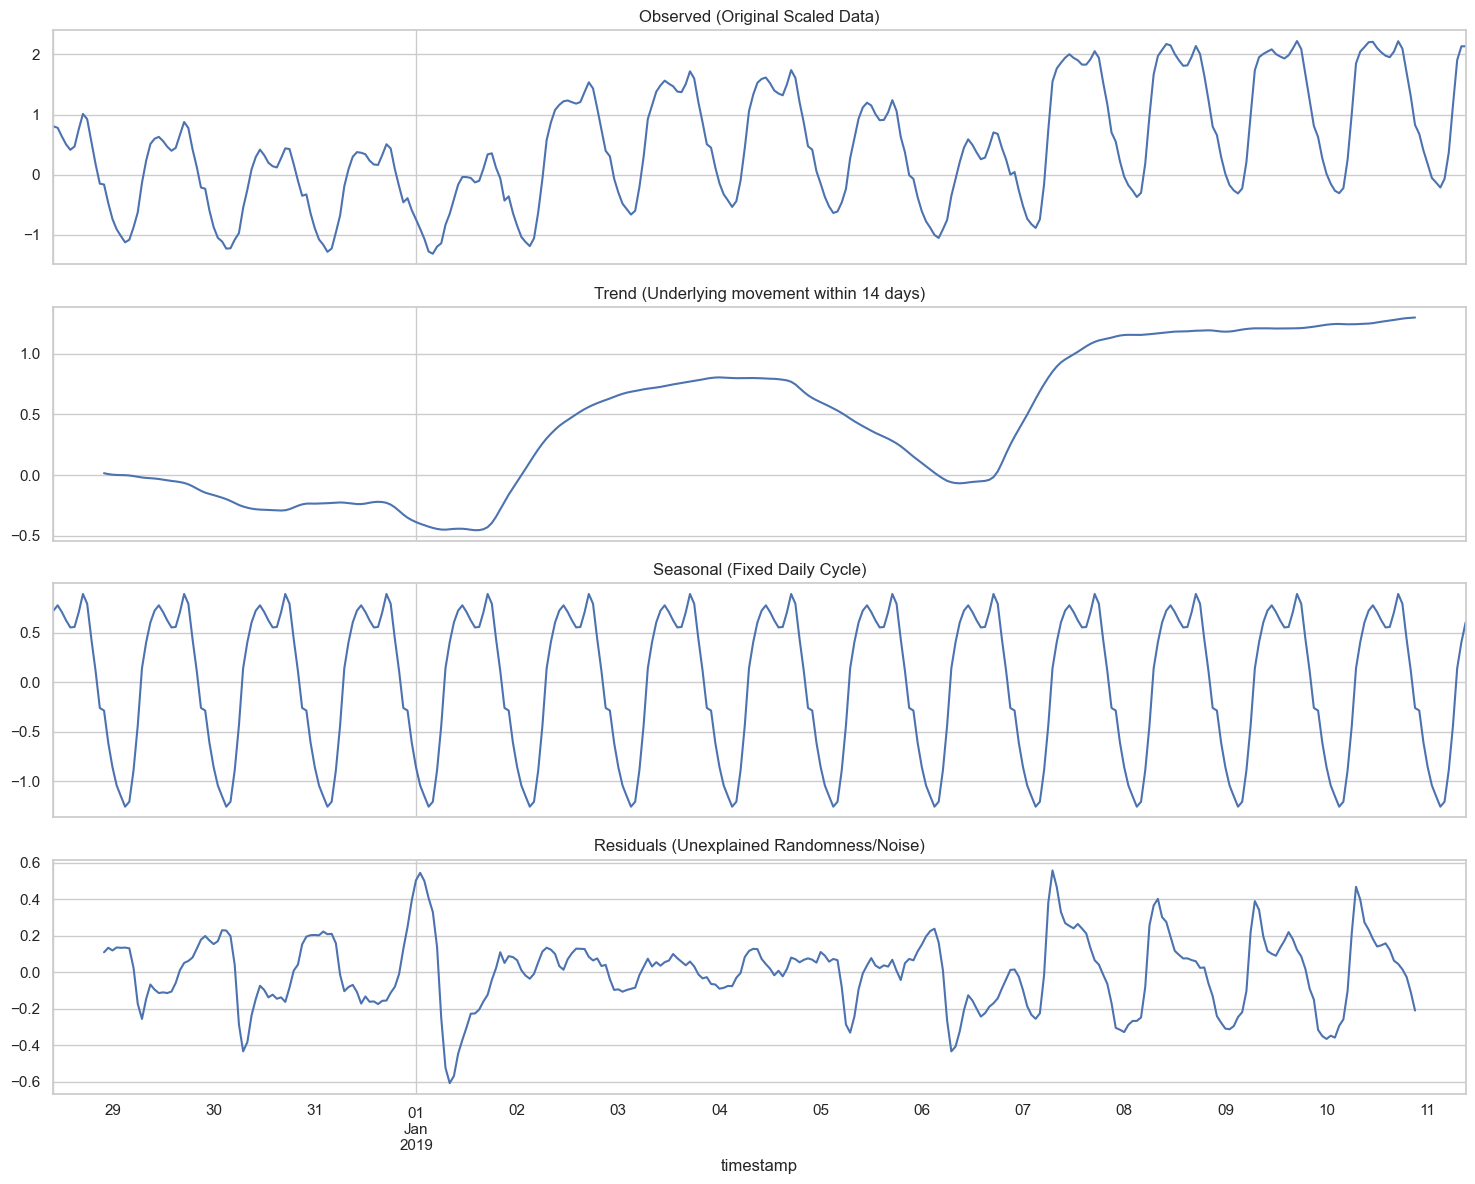

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Prepare data: Ensure index is datetime and has a frequency
# Statsmodels needs a frequency (e.g., 'H' for hourly) to work correctly
df_decomp = df_train.copy()
df_decomp.index = pd.to_datetime(df_decomp.index, utc=True).tz_convert('Europe/Vienna')
df_decomp = df_decomp.asfreq('H') # Set frequency to hourly

# 2. Perform decomposition 
# We look at the last 14 days (24h * 14) to see daily and weekly rhythms
# 'period=24' focuses on the daily cycle
result = seasonal_decompose(df_decomp['load_actual'].tail(24*14), model='additive', period=24)

# 3. Plotting with English titles and comments
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Original time series data
result.observed.plot(ax=ax1)
ax1.set_title('Observed (Original Scaled Data)')

# Long-term trend (moving average)
result.trend.plot(ax=ax2)
ax2.set_title('Trend (Underlying movement within 14 days)')

# The 24-hour seasonal pattern
result.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal (Fixed Daily Cycle)')

# The "leftover" noise after removing trend and seasonality
result.resid.plot(ax=ax4)
ax4.set_title('Residuals (Unexplained Randomness/Noise)')

plt.tight_layout()
plt.show()

Observed vs. Seasonal: The "Observed" data shows clear daily peaks, but the "Seasonal" component isolates the perfect 24-hour cycle. This proves that the daily rhythm is incredibly stable, making hour features highly reliable.

Trend Dynamics: The "Trend" line shows the underlying movement (e.g., a cold spell or a slow week). Because the trend is not flat, it confirms that using Lags (like 24h or 1h) is necessary to help the model adjust to these shifting baselines.

Residual Analysis: The "Residuals" represent the "noise" or unexplained events (like a sudden power plant outage or holiday). If residuals are small, the model will likely have high accuracy; large spikes here indicate where the model might struggle without extra features (like weather).

<Figure size 1200x400 with 0 Axes>

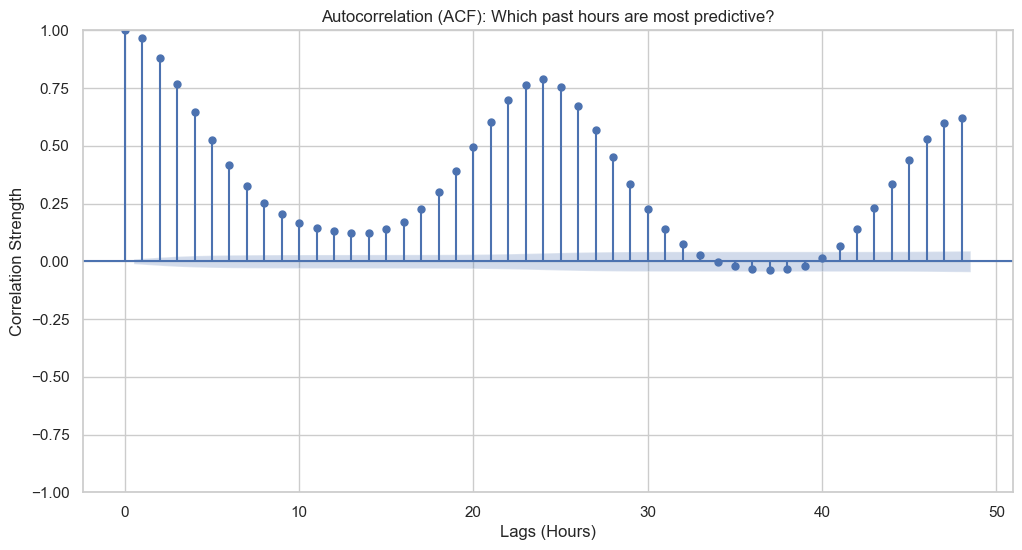

In [24]:
from statsmodels.graphics.tsaplots import plot_acf

# Show how much the current load depends on past hours
plt.figure(figsize=(12, 4))
plot_acf(df_train['load_actual'], lags=48) # Look at the last 2 days
plt.title("Autocorrelation (ACF): Which past hours are most predictive?")
plt.xlabel("Lags (Hours)")
plt.ylabel("Correlation Strength")
plt.show()

Here is the final set of analytical bullet points for your Autocorrelation (ACF) plot, which is the "master plan" for your model's memory:

1. Autocorrelation (ACF): Designing the Model's Memory
The 24-Hour Pulse: The massive spikes at Lag 24 and Lag 48 mathematically prove that the load from yesterday (at the exact same hour) is the strongest predictor for today. Your model must have an input window of at least 24 hours to capture this "daily memory."

Short-Term Momentum: The high correlation in the first 6–8 hours (> 0.75) shows high network "inertia." What happened two hours ago heavily dictates what happens in the next hour.

The 12h Inverse Correlation: The "dip" at Lag 12 shows that noon and midnight are opposites. This wave-like pattern validates that your model needs cyclical features to distinguish between these contrasting states.

Lookback Strategy: Since correlation remains strong even at 48 hours, an LSTM lookback window of 24 or 48 hours is the gold standard for this dataset.

## 🧠 Final Data Strategy & Feature Selection
Based on the Exploratory Data Analysis (EDA), we establish the following strategy for our forecasting model:

1. Feature Retention (The "Core" Set)
Historical Lags (load_actual_lag_1h/24h/168h): Retained as primary predictors. Autocorrelation (ACF) proves that electricity demand is highly regressive; yesterday's and last week's values provide the strongest baseline signal.

Cyclical Time Features (hour_sin/cos, day_sin/cos): Essential to capture the continuous nature of time, solving the "23:00 to 00:00" jump.

Day-Type Indicators (is_weekend, is_holiday): Mandatory. Boxplots show a ~1,200 MW drop on holidays/weekends, which the model must learn to avoid massive over-forecasting.

Renewables (solar, wind): Retained as "external modulators." While correlation is lower than lags, they explain the residual variance (the deviations from the standard daily curve).

2. Features to Drop (Pruning for Efficiency)
Raw Integers (hour, month, day_of_week): DROP. Since we are using Sin/Cos encodings, keeping the raw integers is redundant and can confuse linear or distance-based models.
Also target_load_24h, load_forecast, season_Spring

3. Model Architecture Decision
Model: LSTM (Long Short-Term Memory).

Reasoning: The ACF analysis shows strong dependencies up to 48 hours. An LSTM is specifically designed to handle these sequential dependencies and "memory" effects better than standard regression models.

Lookback Window: Set to 24 or 48 hours to fully capture the daily periodicity identified in the decomposition.

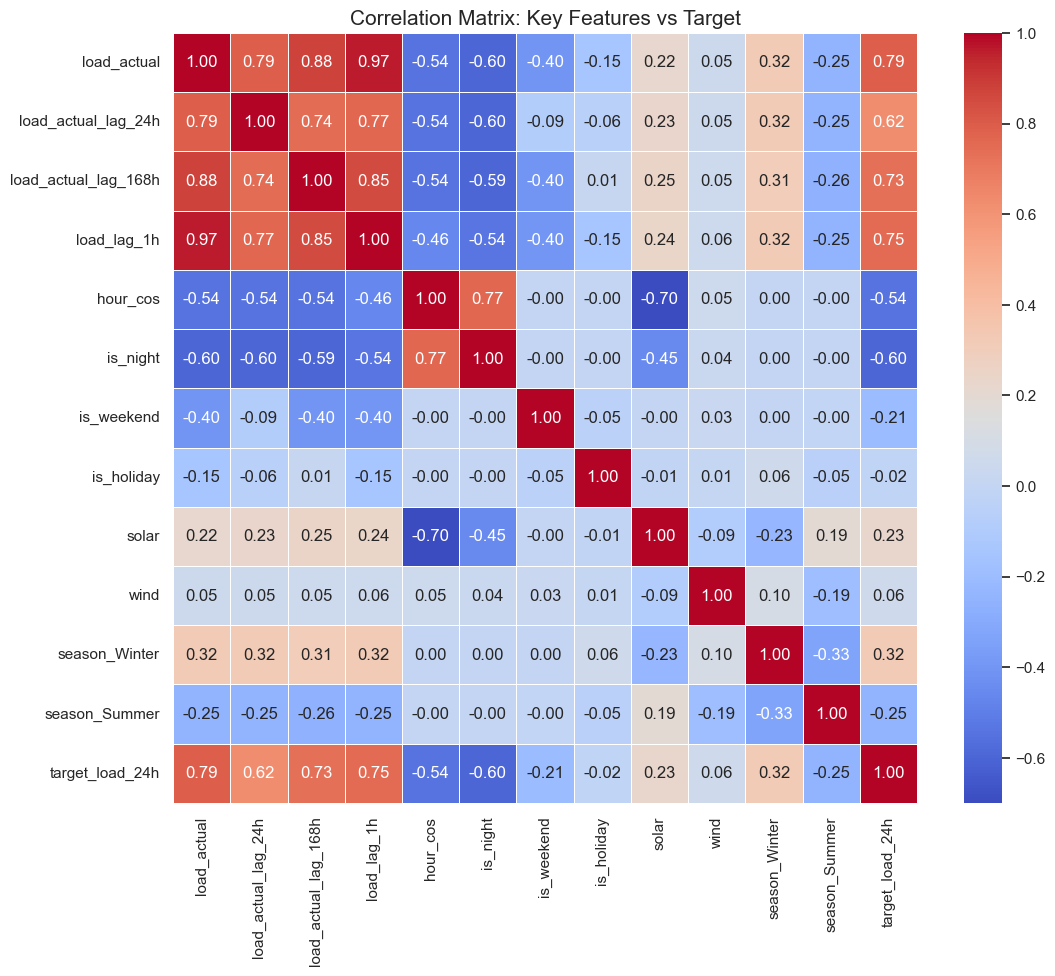

In [39]:
# 1. Liste der relevanten Features (ohne die redundanten rohen Spalten)
relevant_features = [
    'load_actual', 'load_actual_lag_24h', 'load_actual_lag_168h', 'load_lag_1h',
    'hour_cos', 'is_night', 'is_weekend', 'is_holiday',
    'solar', 'wind', 'season_Winter', 'season_Summer', 
    'target_load_24h'
]

# 2. Korrelationsmatrix berechnen
corr_matrix = df_train[relevant_features].corr()

# 3. Heatmap plotten
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix: Key Features vs Target', fontsize=15)
plt.show()

1. The "Power Players" (High Positive Correlation > 0.7)
load_actual, load_lag_1h, load_actual_lag_168h: These show the strongest correlation (up to 0.79) with our target.

Insight: The current load and the load from exactly one week ago are the most reliable indicators. This confirms that the energy grid follows a very strict weekly routine.

2. The "Inhibitors" (Strong Negative Correlation < -0.5)
is_night (-0.60) & hour_cos (-0.54): These features have a strong inverse relationship with the load.

Insight: As soon as these values rise (meaning it's late at night), the load drops significantly. These features will help the model "brake" the prediction during the night hours to avoid over-estimation.

3. The "Context Modulators" (Moderate Correlation 0.2 - 0.4)
season_Winter (0.32) vs. season_Summer (-0.25): There is a clear seasonal delta. Winter increases the base load, while summer decreases it.

is_weekend (-0.21): Even though it's lower than the lags, it confirms a systemic drop in demand on Saturdays and Sundays.

solar (0.23): Moderate correlation shows that high solar production (daytime) typically coincides with high industrial demand, but it also creates the "net load" variance the model needs to learn.

4. The "Noise" Variable: wind (0.06)
Insight: Wind shows almost no linear correlation with the load. This proves that wind energy is highly stochastic (random) in this dataset.

Strategy: We keep it in the model because an LSTM can find non-linear patterns (e.g., a sudden wind gust dropping the net load) that this simple matrix cannot show.